### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [1]:
import tensorflow as tf
tf.set_random_seed(42)

C:\ProgramData\Anaconda3\lib\site-packages\h5py\__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters


In [2]:
tf.__version__

'1.12.0'

### Collect Data

In [3]:
import keras

Using TensorFlow backend.


In [4]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
trainX.shape

(60000, 28, 28)

In [7]:
trainY.shape

(60000,)

In [8]:
print(testY[0:10])

[9 2 1 1 6 1 4 6 5 7]


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [9]:
tf.keras.utils.to_categorical(trainY)

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [10]:
tf.keras.utils.to_categorical(testY)

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [11]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000,)
First 5 examples now are:  [9 0 0 3 0]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

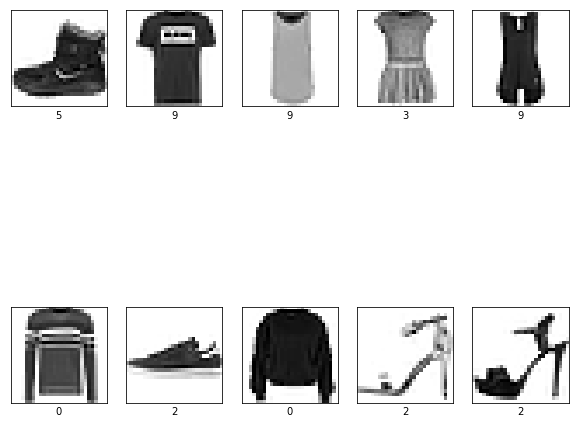

In [12]:
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i], cmap=plt.cm.binary)
    plt.xlabel(trainY[trainY[i]])
plt.show()

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [34]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

In [37]:
model1 = Sequential([keras.layers.Flatten(input_shape=(28, 28))])
model1.add(Dense(100, activation='relu'))
model1.add(Dense(10, activation='sigmoid'))

In [38]:
model1.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

### Execute the model using model.fit()

In [39]:
model1.fit(trainX, trainY, epochs=50)

Epoch 1/50
60000/60000 [==============================] - 7s 114us/step - loss: 5.0499 - acc: 0.0999
Epoch 2/50
60000/60000 [==============================] - 6s 100us/step - loss: 3.8095 - acc: 0.1000
Epoch 3/50
60000/60000 [==============================] - 6s 95us/step - loss: 3.8090 - acc: 0.1000
Epoch 4/50
60000/60000 [==============================] - 6s 96us/step - loss: 3.8090 - acc: 0.1000
Epoch 5/50
60000/60000 [==============================] - 6s 98us/step - loss: 3.8090 - acc: 0.1000
Epoch 6/50
60000/60000 [==============================] - 6s 102us/step - loss: 3.8090 - acc: 0.1000
Epoch 7/50
60000/60000 [==============================] - 6s 100us/step - loss: 3.8090 - acc: 0.1000
Epoch 8/50
60000/60000 [==============================] - 6s 101us/step - loss: 3.8090 - acc: 0.1000
Epoch 9/50
60000/60000 [==============================] - 6s 101us/step - loss: 3.8090 - acc: 0.1000
Epoch 10/50
60000/60000 [==============================] - 6s 101us/step - loss: 3.8090 - acc:

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [40]:
from keras.layers.normalization import BatchNormalization

In [42]:
model1 = Sequential([keras.layers.Flatten(input_shape=(28, 28))])
model1.add(Dense(100, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dense(10, activation='sigmoid'))
model1.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [43]:
model1.fit(trainX, trainY, epochs=50)

Epoch 1/50
60000/60000 [==============================] - 8s 136us/step - loss: 1.2908 - acc: 0.6754
Epoch 2/50
60000/60000 [==============================] - 7s 117us/step - loss: 0.7522 - acc: 0.7363
Epoch 3/50
60000/60000 [==============================] - 7s 116us/step - loss: 0.4886 - acc: 0.8305
Epoch 4/50
60000/60000 [==============================] - 7s 117us/step - loss: 0.4245 - acc: 0.8510
Epoch 5/50
60000/60000 [==============================] - 7s 111us/step - loss: 0.3964 - acc: 0.8602
Epoch 6/50
60000/60000 [==============================] - 7s 117us/step - loss: 0.3838 - acc: 0.8651
Epoch 7/50
60000/60000 [==============================] - 7s 118us/step - loss: 0.3749 - acc: 0.8677
Epoch 8/50
60000/60000 [==============================] - 7s 119us/step - loss: 0.3646 - acc: 0.8702
Epoch 9/50
60000/60000 [==============================] - 7s 117us/step - loss: 0.3523 - acc: 0.8739
Epoch 10/50
60000/60000 [==============================] - 7s 117us/step - loss: 0.3429 - a

### Execute the model

In [0]:
#Done above. 

### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [44]:
from keras import optimizers

In [24]:
sgd = optimizers.SGD(lr=0.001)
model1 = Sequential([keras.layers.Flatten(input_shape=(28, 28))])
model1.add(Dense(128, activation='relu'))
model1.add(BatchNormalization())
model1.add(Dense(10, activation='sigmoid'))
model1.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [25]:
model1.fit(trainX, trainY, epochs=50)

Epoch 1/20
60000/60000 [==============================] - 7s 118us/step - loss: 1.2388 - acc: 0.6610
Epoch 2/20
60000/60000 [==============================] - 6s 108us/step - loss: 0.7104 - acc: 0.7690
Epoch 3/20
60000/60000 [==============================] - 6s 104us/step - loss: 0.4792 - acc: 0.8311
Epoch 4/20
60000/60000 [==============================] - 6s 107us/step - loss: 0.4223 - acc: 0.8493
Epoch 5/20
60000/60000 [==============================] - 6s 102us/step - loss: 0.3992 - acc: 0.8581
Epoch 6/20
60000/60000 [==============================] - 6s 103us/step - loss: 0.3824 - acc: 0.8644
Epoch 7/20
60000/60000 [==============================] - 6s 102us/step - loss: 0.3639 - acc: 0.8703
Epoch 8/20
60000/60000 [==============================] - 6s 106us/step - loss: 0.3571 - acc: 0.8723
Epoch 9/20
60000/60000 [==============================] - 6s 107us/step - loss: 0.3511 - acc: 0.8742
Epoch 10/20
60000/60000 [==============================] - 6s 103us/step - loss: 0.3409 - a

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [31]:
sgd = optimizers.SGD(lr=0.03)
model2 = Sequential([keras.layers.Flatten(input_shape=(28, 28))])
model2.add(Dense(100, activation='sigmoid'))
model2.add(BatchNormalization())
model2.add(Dense(100, activation='sigmoid'))
model2.add(BatchNormalization())
model2.add(Dense(10, activation='softmax'))
model2.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [33]:
model2.fit(trainX, trainY, epochs=100)

Epoch 1/100
60000/60000 [==============================] - 8s 141us/step - loss: 1.0270 - acc: 0.5993
Epoch 2/100
60000/60000 [==============================] - 8s 131us/step - loss: 1.0030 - acc: 0.5882
Epoch 3/100
60000/60000 [==============================] - 8s 132us/step - loss: 1.0476 - acc: 0.5825
Epoch 4/100
60000/60000 [==============================] - 8s 133us/step - loss: 1.0483 - acc: 0.5827
Epoch 5/100
60000/60000 [==============================] - 8s 137us/step - loss: 0.9868 - acc: 0.5990
Epoch 6/100
60000/60000 [==============================] - 8s 136us/step - loss: 0.9079 - acc: 0.6609
Epoch 7/100
60000/60000 [==============================] - 8s 136us/step - loss: 0.9574 - acc: 0.6186
Epoch 8/100
60000/60000 [==============================] - 8s 134us/step - loss: 0.9050 - acc: 0.6572
Epoch 9/100
60000/60000 [==============================] - 8s 136us/step - loss: 0.8754 - acc: 0.6718
Epoch 10/100
60000/60000 [==============================] - 8s 133us/step - loss: 

60000/60000 [==============================] - 7s 122us/step - loss: 0.7348 - acc: 0.7256
Epoch 81/100
60000/60000 [==============================] - 7s 123us/step - loss: 0.7286 - acc: 0.7425
Epoch 82/100
60000/60000 [==============================] - 8s 137us/step - loss: 0.7085 - acc: 0.7262
Epoch 83/100
60000/60000 [==============================] - 8s 126us/step - loss: 0.7454 - acc: 0.7318
Epoch 84/100
60000/60000 [==============================] - 7s 123us/step - loss: 0.7300 - acc: 0.7208
Epoch 85/100
60000/60000 [==============================] - 7s 123us/step - loss: 0.7235 - acc: 0.7347
Epoch 86/100
60000/60000 [==============================] - 7s 124us/step - loss: 0.7151 - acc: 0.7317
Epoch 87/100
60000/60000 [==============================] - 7s 123us/step - loss: 0.7320 - acc: 0.7131
Epoch 88/100
60000/60000 [==============================] - 7s 124us/step - loss: 0.7353 - acc: 0.7045
Epoch 89/100
60000/60000 [==============================] - 7s 123us/step - loss: 0.71

## Review model

In [0]:
#So we have few models here - 
# 1. relu without batch normalizer with default learning rate
# 2. relu with batch normalizer with default learning rate
# 3. relu with batch normalizer with 0.001 learning rate 
# 4. sigmoid with batch normalizer with learning rate of 0.03. This has more dense layers also. 

# lets run #3 and #4 above with validation set and print the accuracy of the train set. 

In [46]:
model1.fit(trainX, trainY, validation_data=(testX,testY), epochs=20)

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 8s 129us/step - loss: 0.2250 - acc: 0.9172 - val_loss: 0.3743 - val_acc: 0.8716
Epoch 2/20
60000/60000 [==============================] - 7s 118us/step - loss: 0.2292 - acc: 0.9155 - val_loss: 0.3694 - val_acc: 0.8730
Epoch 3/20
60000/60000 [==============================] - 7s 122us/step - loss: 0.2286 - acc: 0.9153 - val_loss: 0.3733 - val_acc: 0.8723
Epoch 4/20
60000/60000 [==============================] - 7s 115us/step - loss: 0.2249 - acc: 0.9175 - val_loss: 0.3685 - val_acc: 0.8755
Epoch 5/20
60000/60000 [==============================] - 7s 123us/step - loss: 0.2235 - acc: 0.9175 - val_loss: 0.3927 - val_acc: 0.8664
Epoch 6/20
60000/60000 [==============================] - 7s 117us/step - loss: 0.2188 - acc: 0.9199 - val_loss: 0.3906 - val_acc: 0.8716
Epoch 7/20
60000/60000 [==============================] - 8s 125us/step - loss: 0.2184 - acc: 0.9213 - val_loss: 0.3768 - 

In [51]:
y_pred_mod1=model1.predict_classes(trainX)

In [53]:
from sklearn import metrics
metrics.accuracy_score(trainY,y_pred_mod1)

0.9363

In [50]:
model2.fit(trainX, trainY, validation_data=(testX,testY), epochs=20)

Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 9s 153us/step - loss: 0.7177 - acc: 0.7148 - val_loss: 0.7382 - val_acc: 0.6973
Epoch 2/20
60000/60000 [==============================] - 9s 158us/step - loss: 0.7392 - acc: 0.7116 - val_loss: 0.7593 - val_acc: 0.7304
Epoch 3/20
60000/60000 [==============================] - 9s 147us/step - loss: 0.7453 - acc: 0.7250 - val_loss: 0.7700 - val_acc: 0.7188
Epoch 4/20
60000/60000 [==============================] - 9s 146us/step - loss: 0.7516 - acc: 0.7286 - val_loss: 0.7329 - val_acc: 0.7361
Epoch 5/20
60000/60000 [==============================] - 9s 146us/step - loss: 0.7118 - acc: 0.7368 - val_loss: 0.6924 - val_acc: 0.7465
Epoch 6/20
60000/60000 [==============================] - 9s 158us/step - loss: 0.7669 - acc: 0.6819 - val_loss: 0.8237 - val_acc: 0.6481
Epoch 7/20
60000/60000 [==============================] - 9s 145us/step - loss: 0.7675 - acc: 0.6992 - val_loss: 0.7511 - 

In [54]:
y_pred_mod2=model2.predict_classes(trainX)

In [55]:
metrics.accuracy_score(trainY,y_pred_mod2)

0.7128666666666666

In [ ]:
#model1 is performing better on training data. 

### Run the model

In [58]:
y_pred_mod1=model1.predict_classes(testX)
metrics.accuracy_score(testY,y_pred_mod1)

0.8733

In [59]:
y_pred_mod2=model2.predict_classes(testX)
metrics.accuracy_score(testY,y_pred_mod2)

0.7088

In [ ]:
#Observations - 
#1. in the model without batch normalizer and relu - Error did not decrease or accuracy did not increase after second epoch.
#2. in the second model (after addition of batch normalizer) - error decreased with each epoch and accuracy increased. 
#3. After adding learning rate - there was not much improvemnt, but accuracy dropped a little and error increased too for same number of epochs.
#4. Adding sigmoid to the dense layers decreased the performance. So relu should be used in dense layers.
